<a href="https://colab.research.google.com/github/saptakkashi123-jpg/Syntecxhub---Project-2---Statistical-plots-distribution-analysis--Data-Science-Name---Saptak-kashi/blob/main/Statistical_plots_%26_distribution_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Region      Score
0      A  74.967142
1      A  68.617357
2      A  76.476885
3      A  85.230299
4      A  67.658466


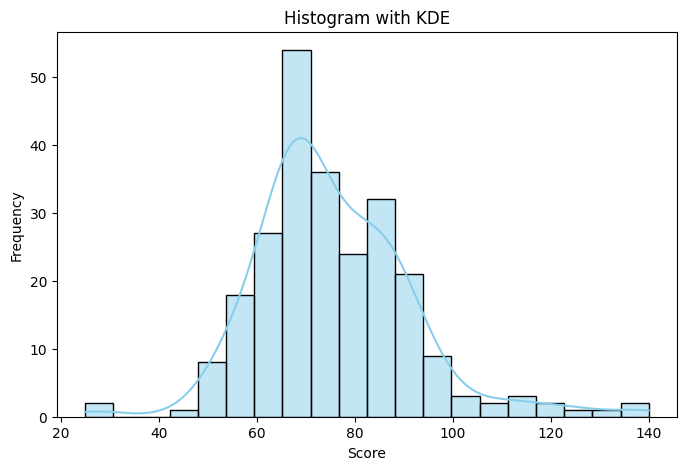

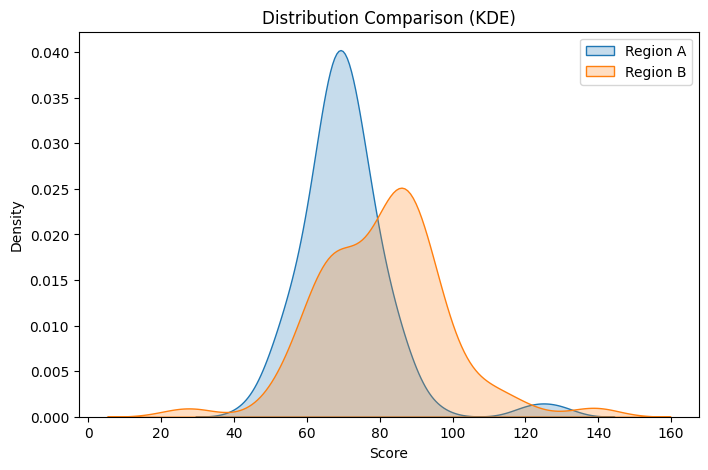

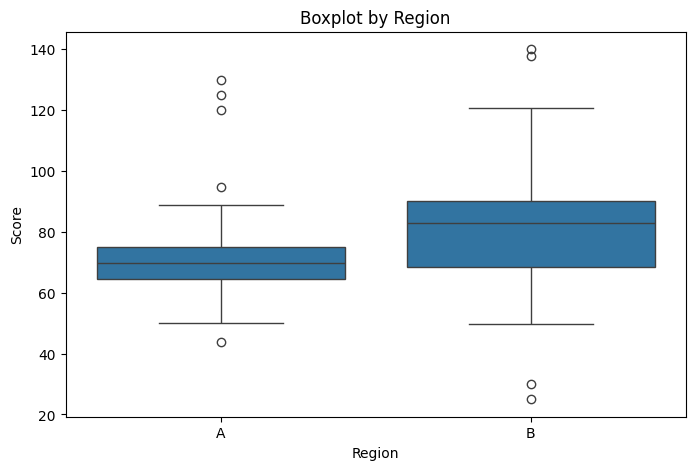


Summary Statistics
        count       mean        std        min        25%        50%  \
Region                                                                 
A       123.0  70.569082  12.593678  43.802549  64.466649  69.641740   
B       123.0  80.722404  17.331890  25.000000  68.329411  82.769508   

              75%    max  
Region                    
A       75.049908  130.0  
B       90.021135  140.0  

Outliers Region A
74      43.802549
113     94.632421
120    120.000000
121    125.000000
122    130.000000
Name: Score, dtype: float64

Outliers Region B
212    137.790972
243     25.000000
244     30.000000
245    140.000000
Name: Score, dtype: float64

Skewness
Region A: 1.843
Region B: 0.235

Statistical Distribution Analysis

Region A has an average score around
70.57
with a skewness of 1.84.

Region B has an average score around
80.72
with a skewness of 0.23.

The histogram and KDE plots show that
Region B has a wider spread than Region A.
The boxplots indicate several 

In [ ]:
# PROJECT 2
# Statistical Plots & Distribution Analysis

# Install required libraries (Colab only)
!pip -q install seaborn scipy

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import os

# -------------------------------
# Create Sample Dataset
# -------------------------------

np.random.seed(42)

region_a = np.random.normal(70, 10, 120)
region_b = np.random.normal(80, 15, 120)

# Add Outliers
region_a = np.append(region_a, [120, 125, 130])
region_b = np.append(region_b, [25, 30, 140])

df = pd.DataFrame({
    "Region": ["A"]*len(region_a) + ["B"]*len(region_b),
    "Score": np.concatenate([region_a, region_b])
})

print(df.head())

# Create folder to save outputs
os.makedirs("Output", exist_ok=True)

# ---------------------------------
# Histogram
# ---------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["Score"], bins=20, kde=True, color="skyblue")
plt.title("Histogram with KDE")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.savefig("Output/histogram.png")
plt.show()

# ---------------------------------
# KDE Comparison
# ---------------------------------

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df.Region=="A"],
    x="Score",
    fill=True,
    label="Region A"
)

sns.kdeplot(
    data=df[df.Region=="B"],
    x="Score",
    fill=True,
    label="Region B"
)

plt.title("Distribution Comparison (KDE)")
plt.legend()
plt.savefig("Output/kde_comparison.png")
plt.show()

# ---------------------------------
# Boxplot
# ---------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Region",
    y="Score",
    data=df
)

plt.title("Boxplot by Region")
plt.savefig("Output/boxplot.png")
plt.show()

# ---------------------------------
# Distribution Statistics
# ---------------------------------

print("\nSummary Statistics")
print(df.groupby("Region")["Score"].describe())

# ---------------------------------
# Outlier Detection using IQR
# ---------------------------------

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = series[(series < lower) | (series > upper)]

    return outliers

print("\nOutliers Region A")
print(detect_outliers(df[df.Region=="A"]["Score"]))

print("\nOutliers Region B")
print(detect_outliers(df[df.Region=="B"]["Score"]))

# ---------------------------------
# Skewness
# ---------------------------------

skew_a = skew(df[df.Region=="A"]["Score"])
skew_b = skew(df[df.Region=="B"]["Score"])

print("\nSkewness")
print("Region A:", round(skew_a,3))
print("Region B:", round(skew_b,3))

# ---------------------------------
# Interpretation
# ---------------------------------

interpretation = f"""
Statistical Distribution Analysis

Region A has an average score around
{df[df.Region=='A']['Score'].mean():.2f}
with a skewness of {skew_a:.2f}.

Region B has an average score around
{df[df.Region=='B']['Score'].mean():.2f}
with a skewness of {skew_b:.2f}.

The histogram and KDE plots show that
Region B has a wider spread than Region A.
The boxplots indicate several outliers in
both regions because extreme values were
intentionally added. Region A appears more
consistent, whereas Region B has greater
variability and dispersion.
"""

print(interpretation)

# Save Interpretation
with open("Output/interpretation.txt","w") as f:
    f.write(interpretation)

print("\nAll plots and interpretation have been saved in the Output folder.")